In [1]:
import pandas as pd

df = pd.read_csv('hanoi_weather_air_quality_final.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058 entries, 0 to 24057
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  24058 non-null  object 
 1   year      24058 non-null  int64  
 2   month     24058 non-null  int64  
 3   day       24058 non-null  int64  
 4   hour      24058 non-null  int64  
 5   weekday   24058 non-null  int64  
 6   temp      24024 non-null  float64
 7   app_temp  24024 non-null  float64
 8   rh        24024 non-null  float64
 9   wind_spd  24024 non-null  float64
 10  wind_dir  24024 non-null  float64
 11  pres      24024 non-null  float64
 12  vis       24017 non-null  float64
 13  clouds    24024 non-null  float64
 14  precip    24024 non-null  float64
 15  uv        24024 non-null  float64
 16  dewpt     24024 non-null  float64
 17  aqi       24058 non-null  int64  
 18  pm25      24058 non-null  float64
 19  pm10      24058 non-null  float64
 20  o3        24058 non-null  fl

In [2]:
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
print("Các cột không phải số:", non_numeric_columns.tolist())

Các cột không phải số: ['datetime']


In [4]:
try:
    df['datetime'] = pd.to_datetime(df['datetime'])
    print(" Đã parse datetime thành công với format tự động")
except:
    df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d %H:%M:%S')
    print(" Đã parse datetime thành công với format '%Y-%m-%d %H:%M:%S'")

# Tạo time features
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

# Loại bỏ các cột không cần thiết (chỉ drop những cột tồn tại)
columns_to_drop = []
for col in ['timestamp_utc', 'ts', 'datetime', 'timestamp_local']:
    if col in df.columns:
        columns_to_drop.append(col)

if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print(f"Đã loại bỏ các cột: {columns_to_drop}")
else:
    # Chỉ drop datetime vì đã tạo time features
    df = df.drop(columns=['datetime'])
    print("Đã loại bỏ cột datetime")

print("\nDữ liệu sau khi xử lý:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

 Đã parse datetime thành công với format tự động
Đã loại bỏ các cột: ['datetime']

Dữ liệu sau khi xử lý:
   year  month  day  hour  weekday  temp  app_temp    rh  wind_spd  wind_dir  \
0  2022     12   31    17        5  14.8      14.8  73.0      0.66     310.0   
1  2022     12   31    18        5  14.6      14.6  75.0      1.00     360.0   
2  2022     12   31    19        5  14.3      14.3  79.0      1.00     345.0   
3  2022     12   31    20        5  14.1      14.1  82.0      1.00     335.0   
4  2022     12   31    21        5  13.8      13.8  86.0      1.00     320.0   

   ...  precip   uv  dewpt  aqi  pm25   pm10    o3   so2  no2     co  
0  ...     0.0  0.0   10.0  155  59.0   73.8  55.7  62.3  9.0  224.5  
1  ...     0.0  0.0   10.2  171  71.0   88.8  56.0  59.0  6.0  206.0  
2  ...     0.0  0.0   10.7  179  77.0   96.3  54.0  58.0  6.0  203.7  
3  ...     0.0  0.0   11.0  199  92.0  115.0  52.0  57.0  6.0  201.3  
4  ...     0.0  0.0   11.5  161  64.0   80.0  50.0  56.0  

In [5]:
num_features = df.shape[1]  # Số cột (đặc trưng)
num_samples = df.shape[0]   # Số dòng (mẫu)

print(f"Số lượng đặc trưng: {num_features}")
print(f"Số lượng mẫu: {num_samples}")
print(f"Tỷ lệ đặc trưng/mẫu: {num_features / num_samples:.2f}")

Số lượng đặc trưng: 23
Số lượng mẫu: 24058
Tỷ lệ đặc trưng/mẫu: 0.00


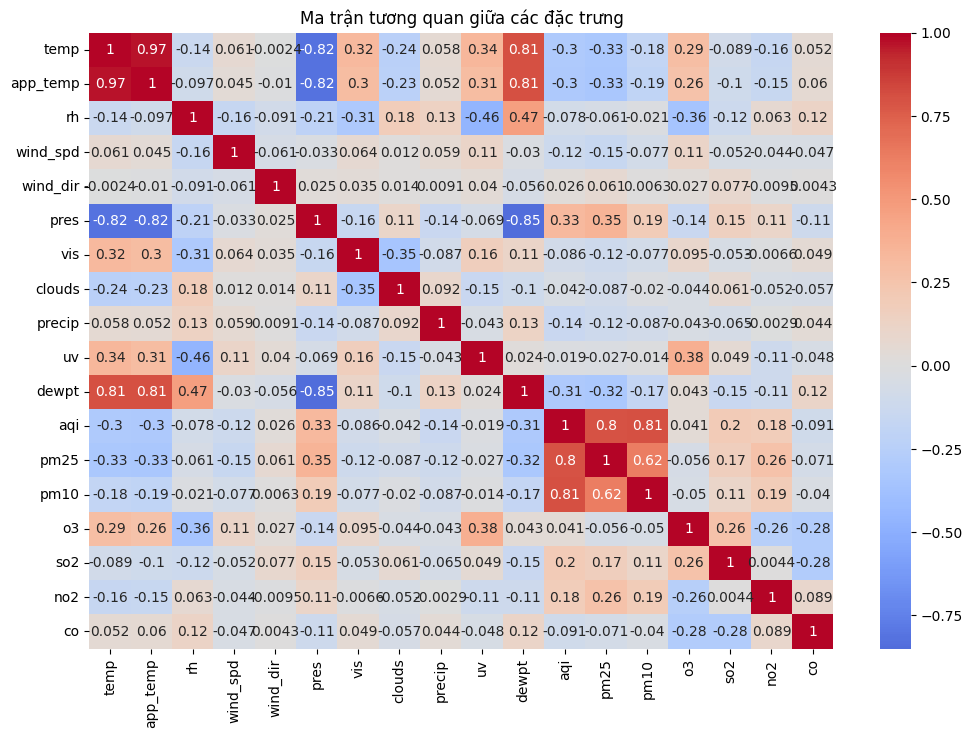

Các cặp đặc trưng có tương quan cao:
temp      app_temp    0.967149
app_temp  temp        0.967149
aqi       pm10        0.811827
pm10      aqi         0.811827
app_temp  dewpt       0.806783
dewpt     app_temp    0.806783
          temp        0.806296
temp      dewpt       0.806296
dtype: float64


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

# Hiển thị ma trận tương quan
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

# Kiểm tra các cặp đặc trưng có tương quan cao
high_corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs < 1] 
print("Các cặp đặc trưng có tương quan cao:")
print(high_corr_pairs[high_corr_pairs > 0.8]) 

In [9]:
print("="*70)
print("XỬ LÝ MULTICOLLINEARITY - LOẠI BỎ CÁC ĐỶC TRƯNG TƯƠNG QUAN CAO")
print("="*70)


print(f"\nCác cột hiện tại: {df.columns.tolist()}")

columns_to_remove = []
if 'app_temp' in df.columns:
    columns_to_remove.append('app_temp')

if 'aqi' in df.columns:
    columns_to_remove.append('aqi') 

# Loại bỏ các cột tương quan cao
if columns_to_remove:
    df_cleaned = df.drop(columns=columns_to_remove)
    print(f"Shape trước: {df.shape}")
    print(f"Shape sau: {df_cleaned.shape}")
    
    # Cập nhật dataframe
    df = df_cleaned.copy()
    print(f"\n Đã cập nhật dataframe với {len(df.columns)} features")
else:
    print("\n Không cần loại bỏ thêm cột nào")

print(f"\nCác features còn lại: {df.columns.tolist()}")

# Tính lại ma trận tương quan sau khi loại bỏ
print("\n" + "="*50)
print("MA TRẬN TƯƠNG QUAN SAU KHI XỬ LÝ")
print("="*50)

numeric_cols_cleaned = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix_cleaned = df[numeric_cols_cleaned].corr()

# Kiểm tra lại các cặp tương quan cao
high_corr_pairs_cleaned = correlation_matrix_cleaned.unstack().sort_values(ascending=False)
high_corr_pairs_cleaned = high_corr_pairs_cleaned[high_corr_pairs_cleaned < 1]
remaining_high_corr = high_corr_pairs_cleaned[high_corr_pairs_cleaned > 0.8]

if len(remaining_high_corr) > 0:
    print("Các cặp tương quan cao còn lại:")
    print(remaining_high_corr.head(10))
else:
    print("Không còn cặp nào có tương quan > 0.8")

print("\n" + "="*70)

XỬ LÝ MULTICOLLINEARITY - LOẠI BỎ CÁC ĐỶC TRƯNG TƯƠNG QUAN CAO

Các cột hiện tại: ['year', 'month', 'day', 'hour', 'weekday', 'temp', 'rh', 'wind_spd', 'wind_dir', 'pres', 'vis', 'clouds', 'precip', 'uv', 'dewpt', 'pm25', 'pm10', 'o3', 'so2', 'no2', 'co']

 Không cần loại bỏ thêm cột nào

Các features còn lại: ['year', 'month', 'day', 'hour', 'weekday', 'temp', 'rh', 'wind_spd', 'wind_dir', 'pres', 'vis', 'clouds', 'precip', 'uv', 'dewpt', 'pm25', 'pm10', 'o3', 'so2', 'no2', 'co']

MA TRẬN TƯƠNG QUAN SAU KHI XỬ LÝ
Các cặp tương quan cao còn lại:
temp   dewpt    0.806296
dewpt  temp     0.806296
dtype: float64



In [10]:
print("="*70)
print("KIỂM TRA VÀ XỬ LÝ MISSING DATA")
print("="*70)

# 1. Kiểm tra missing values tổng quan
print(" TỔNG QUAN MISSING DATA:")
print("-" * 50)
missing_summary = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing Count': missing_summary.values,
    'Missing %': missing_percentage.values
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# 2. Hiển thị thống kê chi tiết
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
overall_missing_rate = (total_missing / total_cells) * 100

print(f"\n THỐNG KÊ TỔNG THỂ:")
print(f"   • Tổng số cells: {total_cells:,}")
print(f"   • Tổng missing values: {total_missing:,}")
print(f"   • Tỷ lệ missing tổng thể: {overall_missing_rate:.2f}%")

# 3. Phân tích missing patterns
if total_missing > 0:
    print(f"\n PHÂN TÍCH MISSING PATTERNS:")
    print("-" * 50)
    
    # Tìm các cột có missing values
    cols_with_missing = missing_df[missing_df['Missing Count'] > 0]['Column'].tolist()
    
    if cols_with_missing:
        print(f"Các cột có missing data: {cols_with_missing}")
        
        # Kiểm tra missing patterns
        for col in cols_with_missing[:5]:  # Chỉ hiển thị top 5
            missing_count = missing_summary[col]
            missing_pct = missing_percentage[col]
            print(f"   • {col}: {missing_count} ({missing_pct:.1f}%)")
            
            # Hiển thị mẫu dữ liệu missing
            missing_indices = df[df[col].isnull()].index[:3]
            if len(missing_indices) > 0:
                print(f"     Mẫu missing indices: {missing_indices.tolist()}")

# 4. Chiến lược xử lý missing data
print(f"\n  CHIẾN LƯỢC XỬ LÝ:")
print("-" * 50)

if total_missing == 0:
    print(" KHÔNG CÓ MISSING DATA - Dataset đã sạch!")
else:
    print("  CÓ MISSING DATA - Cần xử lý:")
    
    # Xử lý theo từng loại cột
    df_cleaned = df.copy()
    
    for col in cols_with_missing:
        missing_count = missing_summary[col]
        missing_pct = missing_percentage[col]
        
        if missing_pct > 50:
            print(f"   • {col}: {missing_pct:.1f}% missing → DROP COLUMN")
            df_cleaned = df_cleaned.drop(columns=[col])
            
        elif missing_pct > 20:
            print(f"   • {col}: {missing_pct:.1f}% missing → DROP ROWS")
            df_cleaned = df_cleaned.dropna(subset=[col])
            
        else:
            # Xử lý theo kiểu dữ liệu
            if df[col].dtype in ['int64', 'float64']:
                # Numerical: dùng median
                median_val = df[col].median()
                df_cleaned[col] = df_cleaned[col].fillna(median_val)
                print(f"   • {col}: {missing_pct:.1f}% missing → FILL với MEDIAN ({median_val:.2f})")
            else:
                # Categorical: dùng mode
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'Unknown'
                df_cleaned[col] = df_cleaned[col].fillna(mode_val)
                print(f"   • {col}: {missing_pct:.1f}% missing → FILL với MODE ({mode_val})")

    # Cập nhật dataframe
    original_shape = df.shape
    df = df_cleaned.copy()
    new_shape = df.shape
    
    print(f"\n KẾT QUẢ SAU XỬ LÝ:")
    print(f"   • Shape trước: {original_shape}")
    print(f"   • Shape sau: {new_shape}")
    print(f"   • Rows removed: {original_shape[0] - new_shape[0]}")
    print(f"   • Columns removed: {original_shape[1] - new_shape[1]}")

# 5. Kiểm tra lại sau khi xử lý
print(f"\n KIỂM TRA LẠI SAU XỬ LÝ:")
print("-" * 50)
remaining_missing = df.isnull().sum().sum()
if remaining_missing == 0:
    print(" HOÀN TẤT - Không còn missing data!")
else:
    print(f"  Vẫn còn {remaining_missing} missing values cần xử lý thêm")
    remaining_missing_cols = df.isnull().sum()
    print(remaining_missing_cols[remaining_missing_cols > 0])

# 6. Hiển thị info cuối cùng
print(f"\n DATASET CUỐI CÙNG:")
print(f"   • Shape: {df.shape}")
print(f"   • Columns: {df.columns.tolist()}")
print(f"   • Data types: ")
for dtype in df.dtypes.value_counts().items():
    print(f"     - {dtype[0]}: {dtype[1]} columns")

print("\n" + "="*70)

KIỂM TRA VÀ XỬ LÝ MISSING DATA
 TỔNG QUAN MISSING DATA:
--------------------------------------------------
      Column  Missing Count  Missing %
10       vis             41   0.170421
6         rh             34   0.141325
7   wind_spd             34   0.141325
5       temp             34   0.141325
8   wind_dir             34   0.141325
13        uv             34   0.141325
14     dewpt             34   0.141325
11    clouds             34   0.141325
12    precip             34   0.141325
9       pres             34   0.141325

 THỐNG KÊ TỔNG THỂ:
   • Tổng số cells: 505,218
   • Tổng missing values: 347
   • Tỷ lệ missing tổng thể: 0.07%

 PHÂN TÍCH MISSING PATTERNS:
--------------------------------------------------
Các cột có missing data: ['vis', 'rh', 'wind_spd', 'temp', 'wind_dir', 'uv', 'dewpt', 'clouds', 'precip', 'pres']
   • vis: 41 (0.2%)
     Mẫu missing indices: [720, 1369, 2090]
   • rh: 34 (0.1%)
     Mẫu missing indices: [720, 1369, 2090]
   • wind_spd: 34 (0.1%)
   

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['pm25']) # Đặc trưng
y = df['pm25']  # Target

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

print("Kích thước tập huấn luyện:", X_train.shape, y_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape, y_test.shape)


Kích thước tập huấn luyện: (19246, 20) (19246,)
Kích thước tập kiểm tra: (4812, 20) (4812,)


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
print("="*70)
print("CHUẨN BỊ DỮ LIỆU: GỐC VÀ ĐÃ CHUẨN HÓA")
print("="*70)

# Dataset 1: Dữ liệu GỐC (không chuẩn hóa)
X_train_original = X_train.copy()
X_test_original = X_test.copy()

print("Dataset 1: Dữ liệu GỐC (không chuẩn hóa)")
print(f"   - X_train shape: {X_train_original.shape}")
print(f"   - X_test shape: {X_test_original.shape}")

# Dataset 2: Dữ liệu ĐÃ CHUẨN HÓA
print("\nDataset 2: Dữ liệu ĐÃ CHUẨN HÓA (StandardScaler)")
print(f"   - X_train shape: {X_train_scaled.shape}")
print(f"   - X_test shape: {X_test_scaled.shape}")

print("\nThống kê dữ liệu GỐC (5 features đầu tiên):")
print(X_train_original.iloc[:3, :5])

print("\nThống kê dữ liệu ĐÃ CHUẨN HÓA (5 features đầu tiên):")
print(pd.DataFrame(X_train_scaled[:3, :5], columns=X_train.columns[:5]))

print("="*70)

CHUẨN BỊ DỮ LIỆU: GỐC VÀ ĐÃ CHUẨN HÓA
Dataset 1: Dữ liệu GỐC (không chuẩn hóa)
   - X_train shape: (19246, 20)
   - X_test shape: (4812, 20)

Dataset 2: Dữ liệu ĐÃ CHUẨN HÓA (StandardScaler)
   - X_train shape: (19246, 20)
   - X_test shape: (4812, 20)

Thống kê dữ liệu GỐC (5 features đầu tiên):
       year  month  day  hour  weekday
19578  2025      4   21     8        0
17229  2025      1   10    14        4
3497   2023      5   30     6        1

Thống kê dữ liệu ĐÃ CHUẨN HÓA (5 features đầu tiên):
       year     month       day      hour   weekday
0  1.319565 -0.669076  0.672998 -0.505319 -1.499098
1  1.319565 -1.572813 -0.615215  0.360376  0.500253
2 -1.174430 -0.367831  1.726990 -0.793884 -0.999260


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import time

print("\n" + "="*70)
print("PHẦN 1: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU GỐC (KHÔNG CHUẨN HÓA)")
print("="*70 + "\n")

# Khởi tạo các mô hình
models_original = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Dictionary lưu kết quả
results_original = {}

# Huấn luyện và đánh giá từng mô hình
for name, model in models_original.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Huấn luyện
    model.fit(X_train_original, y_train)
    
    # Dự đoán
    y_pred_train = model.predict(X_train_original)
    y_pred_test = model.predict(X_test_original)
    
    # Tính toán metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = train_mse ** 0.5
    train_r2 = r2_score(y_train, y_pred_train)
    
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = test_mse ** 0.5
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    elapsed_time = time.time() - start_time
    
    # Lưu kết quả
    results_original[name] = {
        "Train MSE": train_mse,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test R²": test_r2,
        "Training Time": elapsed_time,
        "Model": model
    }
    
    print(f"   {name}: R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}, Time = {elapsed_time:.2f}s\n")

# Hiển thị kết quả tổng hợp
print("="*70)
print("KẾT QUẢ TRÊN DỮ LIỆU GỐC")
print("="*70)

results_df_original = pd.DataFrame({
    'Model': list(results_original.keys()),
    'Train R²': [results_original[m]['Train R²'] for m in results_original.keys()],
    'Test R²': [results_original[m]['Test R²'] for m in results_original.keys()],
    'Test RMSE': [results_original[m]['Test RMSE'] for m in results_original.keys()],
    'Test MAE': [results_original[m]['Test MAE'] for m in results_original.keys()],
    'Time (s)': [results_original[m]['Training Time'] for m in results_original.keys()]
})

results_df_original = results_df_original.sort_values('Test R²', ascending=False)
print(results_df_original.to_string(index=False))
print("="*70)


PHẦN 1: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU GỐC (KHÔNG CHUẨN HÓA)

Training Linear Regression...
   Linear Regression: R² = 0.5276, RMSE = 28.1601, Time = 0.07s

Training Random Forest...
   Random Forest: R² = 0.9571, RMSE = 8.4904, Time = 4.28s

Training XGBoost...
   XGBoost: R² = 0.9629, RMSE = 7.8928, Time = 0.48s

KẾT QUẢ TRÊN DỮ LIỆU GỐC
            Model  Train R²  Test R²  Test RMSE  Test MAE  Time (s)
          XGBoost  0.991629 0.962887   7.892804  4.104565  0.475345
    Random Forest  0.993303 0.957054   8.490420  4.002344  4.279708
Linear Regression  0.502015 0.527579  28.160076 16.922928  0.071086


In [16]:
print("\n" + "="*70)
print("PHẦN 2: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA")
print("="*70 + "\n")

# Khởi tạo các mô hình
models_scaled = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Dictionary lưu kết quả
results_scaled = {}

# Huấn luyện và đánh giá từng mô hình
for name, model in models_scaled.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Huấn luyện
    model.fit(X_train_scaled, y_train)
    
    # Dự đoán
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Tính toán metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = train_mse ** 0.5
    train_r2 = r2_score(y_train, y_pred_train)
    
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = test_mse ** 0.5
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    elapsed_time = time.time() - start_time
    
    # Lưu kết quả
    results_scaled[name] = {
        "Train MSE": train_mse,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test R²": test_r2,
        "Training Time": elapsed_time,
        "Model": model
    }
    
    print(f"   {name}: R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}, Time = {elapsed_time:.2f}s\n")

# Hiển thị kết quả tổng hợp
print("="*70)
print("KẾT QUẢ TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA")
print("="*70)

results_df_scaled = pd.DataFrame({
    'Model': list(results_scaled.keys()),
    'Train R²': [results_scaled[m]['Train R²'] for m in results_scaled.keys()],
    'Test R²': [results_scaled[m]['Test R²'] for m in results_scaled.keys()],
    'Test RMSE': [results_scaled[m]['Test RMSE'] for m in results_scaled.keys()],
    'Test MAE': [results_scaled[m]['Test MAE'] for m in results_scaled.keys()],
    'Time (s)': [results_scaled[m]['Training Time'] for m in results_scaled.keys()]
})

results_df_scaled = results_df_scaled.sort_values('Test R²', ascending=False)
print(results_df_scaled.to_string(index=False))
print("="*70)


PHẦN 2: HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA

Training Linear Regression...
   Linear Regression: R² = 0.5276, RMSE = 28.1601, Time = 0.02s

Training Random Forest...
   Random Forest: R² = 0.9569, RMSE = 8.5012, Time = 4.00s

Training XGBoost...
   XGBoost: R² = 0.9629, RMSE = 7.8928, Time = 0.35s

KẾT QUẢ TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA
            Model  Train R²  Test R²  Test RMSE  Test MAE  Time (s)
          XGBoost  0.991629 0.962887   7.892804  4.104565  0.346697
    Random Forest  0.993296 0.956945   8.501198  4.006269  3.996840
Linear Regression  0.502015 0.527579  28.160076 16.922928  0.020205


In [17]:
print("\n" + "="*70)
print("SO SÁNH KẾT QUẢ: DỮ LIỆU GỐC vs DỮ LIỆU ĐÃ CHUẨN HÓA")
print("="*70 + "\n")

# Tạo DataFrame so sánh
comparison_data = []

for model_name in results_original.keys():
    original_r2 = results_original[model_name]['Test R²']
    original_rmse = results_original[model_name]['Test RMSE']
    original_mae = results_original[model_name]['Test MAE']
    
    scaled_r2 = results_scaled[model_name]['Test R²']
    scaled_rmse = results_scaled[model_name]['Test RMSE']
    scaled_mae = results_scaled[model_name]['Test MAE']
    
    # Tính % thay đổi
    r2_diff = ((scaled_r2 - original_r2) / abs(original_r2)) * 100 if original_r2 != 0 else 0
    rmse_diff = ((scaled_rmse - original_rmse) / original_rmse) * 100 if original_rmse != 0 else 0
    mae_diff = ((scaled_mae - original_mae) / original_mae) * 100 if original_mae != 0 else 0
    
    comparison_data.append({
        'Model': model_name,
        'Original R²': original_r2,
        'Scaled R²': scaled_r2,
        'R² Change (%)': r2_diff,
        'Original RMSE': original_rmse,
        'Scaled RMSE': scaled_rmse,
        'RMSE Change (%)': rmse_diff,
        'Original MAE': original_mae,
        'Scaled MAE': scaled_mae,
        'MAE Change (%)': mae_diff
    })

comparison_df = pd.DataFrame(comparison_data)

# Hiển thị R² comparison
print("SO SÁNH R² SCORE:")
print("-" * 70)
r2_comparison = comparison_df[['Model', 'Original R²', 'Scaled R²', 'R² Change (%)']].copy()
print(r2_comparison.to_string(index=False))

# Hiển thị RMSE comparison
print("\nSO SÁNH RMSE:")
print("-" * 70)
rmse_comparison = comparison_df[['Model', 'Original RMSE', 'Scaled RMSE', 'RMSE Change (%)']].copy()
print(rmse_comparison.to_string(index=False))

# Hiển thị MAE comparison
print("\nSO SÁNH MAE:")
print("-" * 70)
mae_comparison = comparison_df[['Model', 'Original MAE', 'Scaled MAE', 'MAE Change (%)']].copy()
print(mae_comparison.to_string(index=False))

# Tổng kết
print("\n" + "="*70)
print("KẾT LUẬN:")
print("="*70)

for model_name in results_original.keys():
    original_r2 = results_original[model_name]['Test R²']
    scaled_r2 = results_scaled[model_name]['Test R²']
    
    if scaled_r2 > original_r2:
        improvement = ((scaled_r2 - original_r2) / abs(original_r2)) * 100
        print(f"{model_name}: Chuẩn hóa CẢI THIỆN hiệu suất {improvement:+.2f}%")
    elif scaled_r2 < original_r2:
        degradation = ((scaled_r2 - original_r2) / abs(original_r2)) * 100
        print(f"{model_name}: Chuẩn hóa GIẢM hiệu suất {degradation:.2f}%")
    else:
        print(f"{model_name}: Chuẩn hóa KHÔNG ẢNH HƯỞNG")

print("="*70)


SO SÁNH KẾT QUẢ: DỮ LIỆU GỐC vs DỮ LIỆU ĐÃ CHUẨN HÓA

SO SÁNH R² SCORE:
----------------------------------------------------------------------
            Model  Original R²  Scaled R²  R² Change (%)
Linear Regression     0.527579   0.527579   8.417485e-14
    Random Forest     0.957054   0.956945  -1.140059e-02
          XGBoost     0.962887   0.962887   0.000000e+00

SO SÁNH RMSE:
----------------------------------------------------------------------
            Model  Original RMSE  Scaled RMSE  RMSE Change (%)
Linear Regression      28.160076    28.160076    -5.046455e-14
    Random Forest       8.490420     8.501198     1.269518e-01
          XGBoost       7.892804     7.892804     0.000000e+00

SO SÁNH MAE:
----------------------------------------------------------------------
            Model  Original MAE  Scaled MAE  MAE Change (%)
Linear Regression     16.922928   16.922928   -2.099349e-14
    Random Forest      4.002344    4.006269    9.807066e-02
          XGBoost      4.


TRỰC QUAN HÓA KẾT QUẢ SO SÁNH



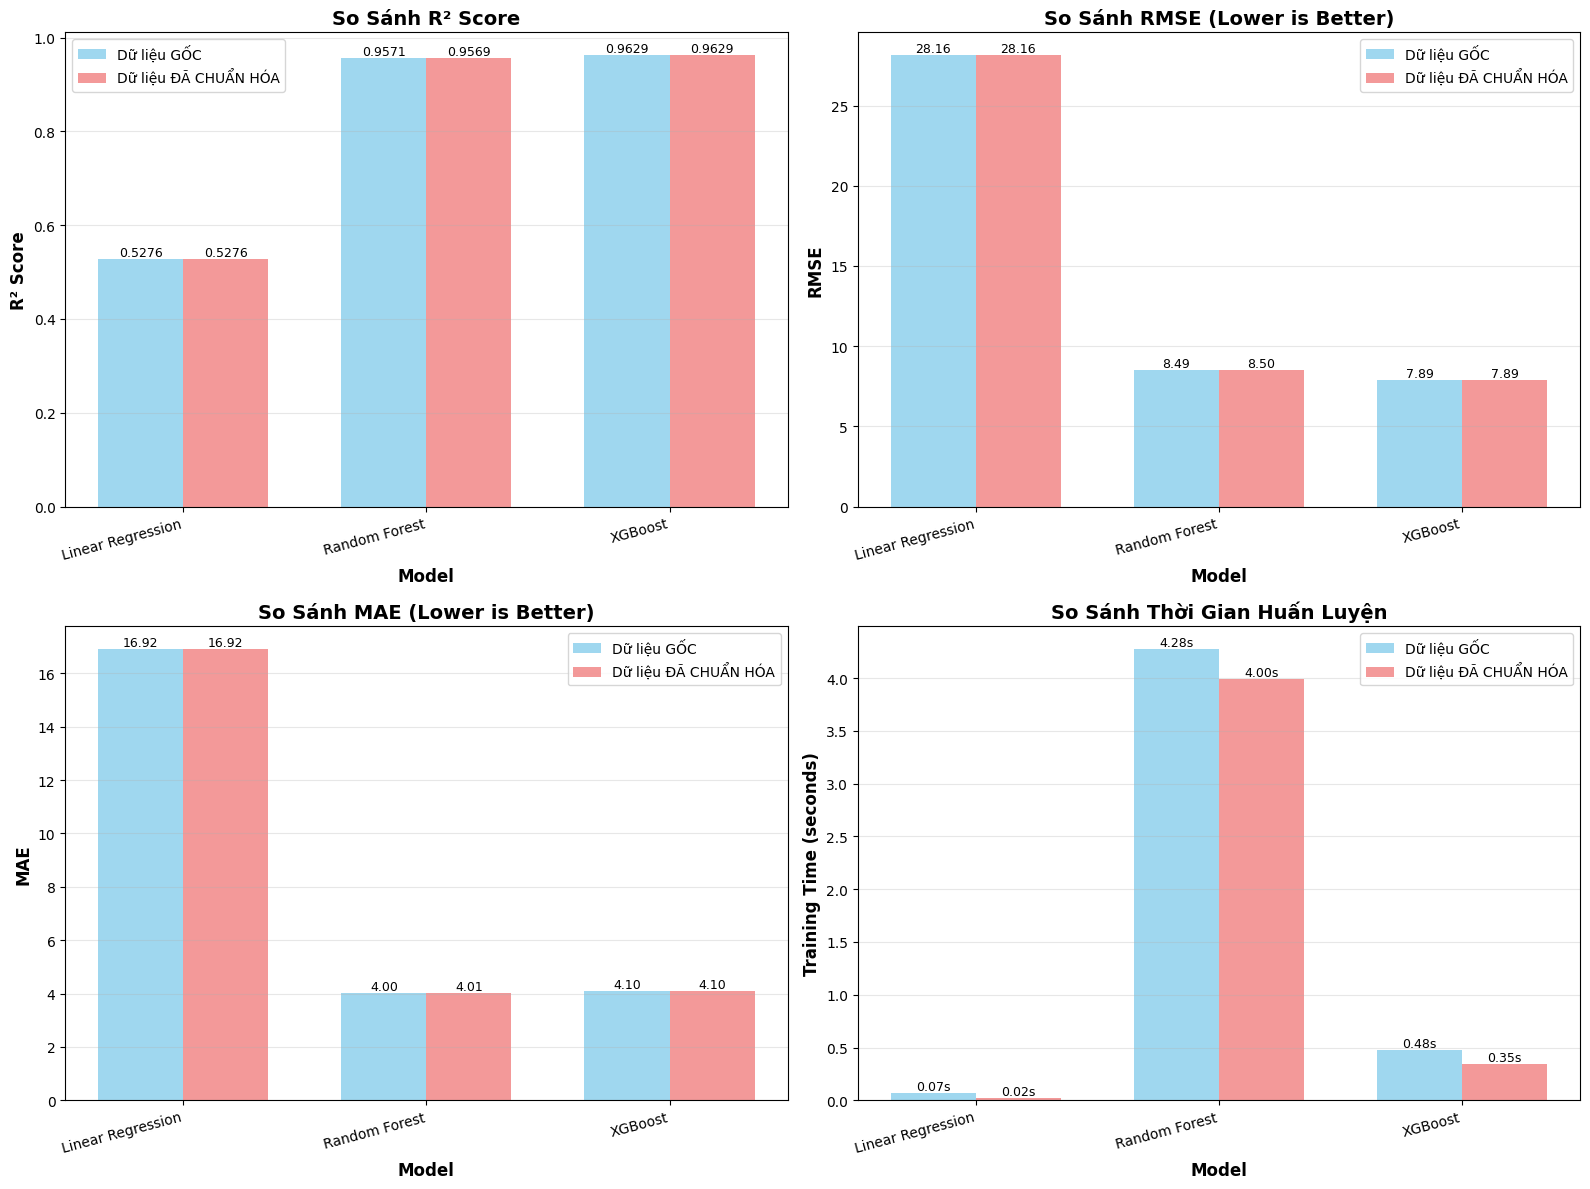

In [18]:
import matplotlib.pyplot as plt
import numpy as np

print("\nTRỰC QUAN HÓA KẾT QUẢ SO SÁNH\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. So sánh R² Score
ax1 = axes[0, 0]
models = list(results_original.keys())
x = np.arange(len(models))
width = 0.35

original_r2 = [results_original[m]['Test R²'] for m in models]
scaled_r2 = [results_scaled[m]['Test R²'] for m in models]

bars1 = ax1.bar(x - width/2, original_r2, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, scaled_r2, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('So Sánh R² Score', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# 2. So sánh RMSE
ax2 = axes[0, 1]
original_rmse = [results_original[m]['Test RMSE'] for m in models]
scaled_rmse = [results_scaled[m]['Test RMSE'] for m in models]

bars3 = ax2.bar(x - width/2, original_rmse, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars4 = ax2.bar(x + width/2, scaled_rmse, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('So Sánh RMSE (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 3. So sánh MAE
ax3 = axes[1, 0]
original_mae = [results_original[m]['Test MAE'] for m in models]
scaled_mae = [results_scaled[m]['Test MAE'] for m in models]

bars5 = ax3.bar(x - width/2, original_mae, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars6 = ax3.bar(x + width/2, scaled_mae, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax3.set_title('So Sánh MAE (Lower is Better)', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 4. So sánh Training Time
ax4 = axes[1, 1]
original_time = [results_original[m]['Training Time'] for m in models]
scaled_time = [results_scaled[m]['Training Time'] for m in models]

bars7 = ax4.bar(x - width/2, original_time, width, label='Dữ liệu GỐC', alpha=0.8, color='skyblue')
bars8 = ax4.bar(x + width/2, scaled_time, width, label='Dữ liệu ĐÃ CHUẨN HÓA', alpha=0.8, color='lightcoral')

ax4.set_xlabel('Model', fontsize=12, fontweight='bold')
ax4.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax4.set_title('So Sánh Thời Gian Huấn Luyện', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, rotation=15, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Thêm giá trị lên các cột
for bars in [bars7, bars8]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
print("="*70)
print("LƯU MÔ HÌNH VÀ SCALER")
print("="*70 + "\n")

import joblib

# Chọn mô hình tốt nhất từ dữ liệu gốc (Random Forest hoặc XGBoost từ results_original)
best_model_name_original = max(results_original, key=lambda x: results_original[x]['Test R²'])
best_model_original = results_original[best_model_name_original]['Model']

# Chọn mô hình tốt nhất từ dữ liệu đã chuẩn hóa
best_model_name_scaled = max(results_scaled, key=lambda x: results_scaled[x]['Test R²'])
best_model_scaled = results_scaled[best_model_name_scaled]['Model']

print(f" Mô hình được chọn từ dữ liệu gốc:")
print(f"   Mô hình: {best_model_name_original}")
print(f"   Test R²: {results_original[best_model_name_original]['Test R²']:.4f}")
print(f"   Test RMSE: {results_original[best_model_name_original]['Test RMSE']:.4f}")
print(f"   Test MAE: {results_original[best_model_name_original]['Test MAE']:.4f}")

print(f"\n Mô hình được chọn từ dữ liệu đã chuẩn hóa:")
print(f"   Mô hình: {best_model_name_scaled}")
print(f"   Test R²: {results_scaled[best_model_name_scaled]['Test R²']:.4f}")
print(f"   Test RMSE: {results_scaled[best_model_name_scaled]['Test RMSE']:.4f}")
print(f"   Test MAE: {results_scaled[best_model_name_scaled]['Test MAE']:.4f}")

# Lưu cả hai mô hình
joblib.dump(best_model_original, 'best_pm25_model_original.pkl')
joblib.dump(best_model_scaled, 'best_pm25_model_scaled.pkl')
# Lưu StandardScaler (QUAN TRỌNG cho prediction notebook)
joblib.dump(scaler, 'pm25_scaler.pkl')

print(f"\n ĐÃ LƯU CÁC FILE:")
print(f"    best_pm25_model_original.pkl")
print(f"    best_pm25_model_scaled.pkl")
print(f"    pm25_scaler.pkl (StandardScaler)")

print("\n" + "="*70)


LƯU MÔ HÌNH VÀ SCALER

 Mô hình được chọn từ dữ liệu gốc:
   Mô hình: XGBoost
   Test R²: 0.9629
   Test RMSE: 7.8928
   Test MAE: 4.1046

 Mô hình được chọn từ dữ liệu đã chuẩn hóa:
   Mô hình: XGBoost
   Test R²: 0.9629
   Test RMSE: 7.8928
   Test MAE: 4.1046

 ĐÃ LƯU CÁC FILE:
    best_pm25_model_original.pkl
    best_pm25_model_scaled.pkl
    pm25_scaler.pkl (StandardScaler)

